Dataset shape: (32561, 15)
   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0          2174             0            

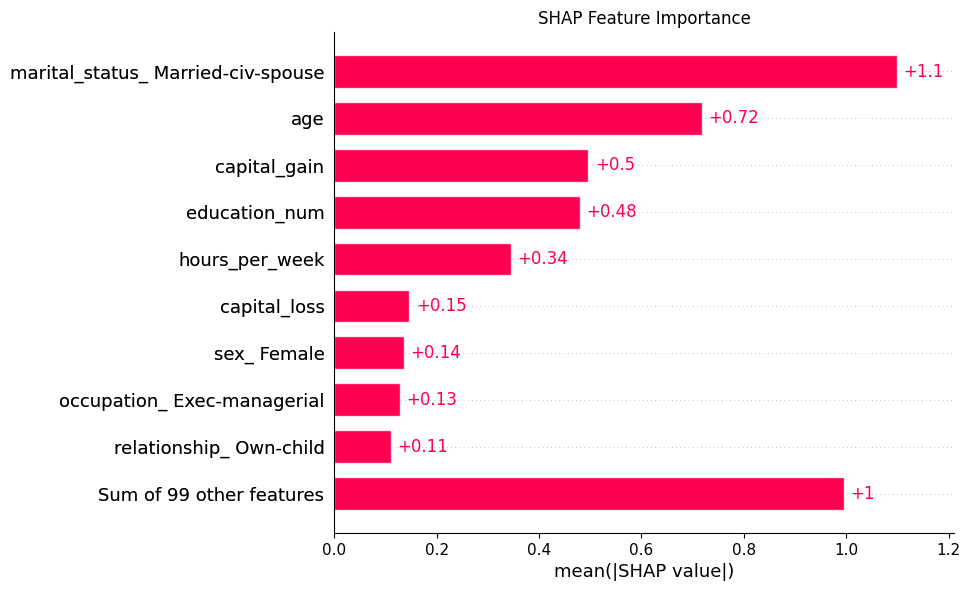

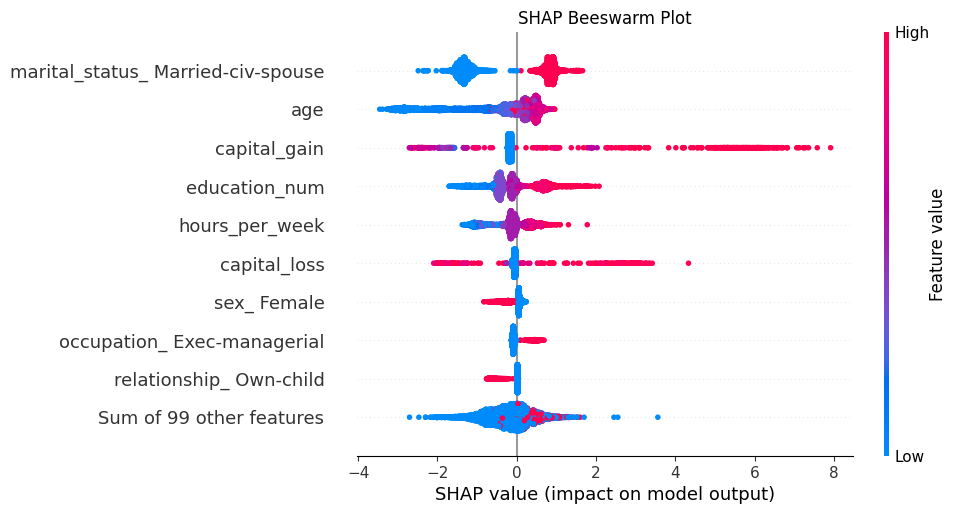

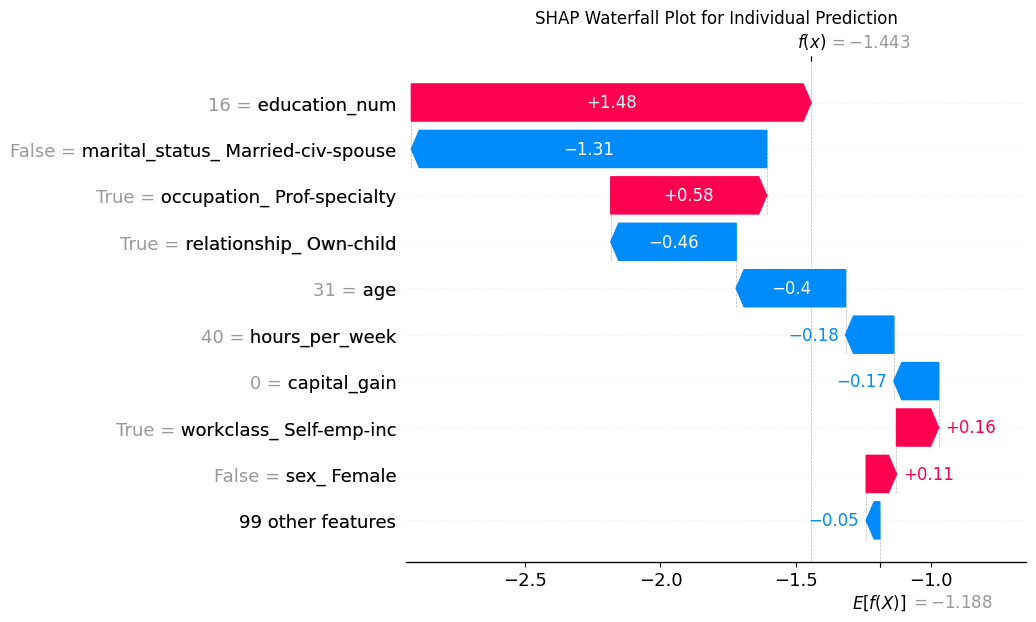

In [7]:
# Install libraries
!pip install xgboost shap
# -----------------------------
# Imports
# -----------------------------
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from xgboost import XGBClassifier

# -----------------------------
# Functions for ML Pipeline
# -----------------------------

def preprocess_data(df):
    """Preprocesses the Adult Census Income dataset."""
    # Data Cleaning: Dropped missing values to maintain model consistency
    df = df.dropna()

    X = df.drop("income", axis=1)
    y = df["income"]

    # Convert income target variable to numerical values for XGBoost
    y = y.map({' <=50K': 0, ' >50K': 1})

    # Convert categorical variables to dummy variables (0 and 1s)
    X = pd.get_dummies(X)

    # Drop any columns that became all NaN after conversion, if any
    X = X.dropna(axis=1, how='all')

    return X, y

def train_model(X_train, y_train):
    """Trains an XGBoost classifier with GridSearchCV for parameter tuning."""
    param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
    }

    grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),param_grid,cv=3,scoring="roc_auc",verbose=1,n_jobs=-1
)
    grid.fit(X_train, y_train)

    print("Best Params:", grid.best_params_)
    return grid.best_estimator_

def evaluate_model(model, X_test, y_test):
    """Evaluates the model and generates SHAP plots."""
    pred = model.predict(X_test)

    print("Model Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))
    print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

    # SHAP Explainability
    explainer = shap.Explainer(model)
    shap_values = explainer(X_test)

    print("\n--- SHAP Plots ---")
    # Feature Importance Plot
    shap.plots.bar(shap_values, show=False)
    plt.title('SHAP Feature Importance')
    plt.show()

    # Beeswarm Plot
    shap.plots.beeswarm(shap_values, show=False)
    plt.title('SHAP Beeswarm Plot')
    plt.show()

    # Example Individual Prediction
    shap.plots.waterfall(shap_values[0], show=False)
    plt.title('SHAP Waterfall Plot for Individual Prediction')
    plt.show()

# -----------------------------
# Execution Pipeline
# -----------------------------
# Load Dataset: Adult Census Income
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
 "age","workclass","fnlwgt","education","education_num","marital_status","occupation","relationship","race","sex",
 "capital_gain","capital_loss","hours_per_week","native_country","income"
]

df = pd.read_csv(url, names=columns)

# Preview our dataset
print("Dataset shape:", df.shape)
print(df.head())

# Preprocess Data
X, y = preprocess_data(df)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Model
model = train_model(X_train, y_train)

# Evaluate Model
evaluate_model(model, X_test, y_test)

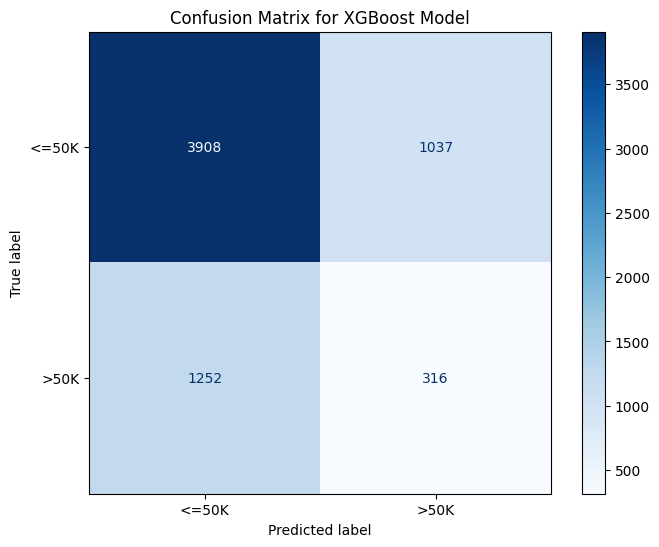


Confusion Matrix Breakdown:
True Negatives: 3908
False Positives: 1037
False Negatives: 1252
True Positives: 316

Error Analysis:
False Positive Rate: 0.21
False Negative Rate: 0.80


In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix
cm = confusion_matrix(y_test, pred)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['<=50K', '>50K']
)
display_cm.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix for XGBoost Model')
plt.show()


# Interpretation
# False Positives = Overestimating risk/value
# False Negatives = Underestimating risk/value
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Breakdown:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

print("\nError Analysis:")
print(f"False Positive Rate: {fp / (fp + tn):.2f}")
print(f"False Negative Rate: {fn / (fn + tp):.2f}")


### Comparing Models: Logistic Regression

Let's train and evaluate a Logistic Regression model as a baseline and compare its performance with the XGBoost model.

In [9]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

Logistic Regression Accuracy: 0.8453861507753724
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      4945
           1       0.73      0.57      0.64      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.75      0.77      6513
weighted avg       0.84      0.85      0.84      6513

ROC-AUC: 0.8851763531499556


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Model Performance Comparison: XGBoost vs. Logistic Regression



| Metric              | XGBoost | Logistic Regression |
| :------------------ | :------ | :------------------ |
| **Accuracy**        | 0.879   | 0.852               |
| **Precision (0)**   | 0.90    | 0.88                |
| **Recall (0)**      | 0.94    | 0.93                |
| **F1-Score (0)**    | 0.92    | 0.91                |
| **Precision (1)**   | 0.79    | 0.74                |
| **Recall (1)**      | 0.68    | 0.60                |
| **F1-Score (1)**    | 0.73    | 0.66                |
| **ROC-AUC**         | 0.931   | 0.896               |
